In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Constants etc.

This is the stuff we adapt according to our files and what we want for our plots

In [2]:
# CONSTANTS
tau_ts = [0.2, 0.1] # response time desired after applying PID
V = 4.6 # voltage applied

# PATHS
data_dir = Path('Dados')
im_dir = Path('../../Imagens')
im_dir.mkdir(parents = True, exist_ok = True)

# FILES
files = ['Log_dt20_2.txt', 'Log_pid_dt20_4V.txt']
names = ['Sem PID', r'Com PID: τ$_c$ = 100ms'] # labels for the dictionary - nao pode ter .

# STUFF FOR ANALYSIS 
n_start = [267, 221]
n_A_min = [348, 302]
n_A_max = [400, -35]
PID_bol = [0, 1] # 1 was PID is already applied when the data was collected, 0 otherwhise


# PRETTY COLORS
plot_colors = ['purple', 'xkcd:dodger blue', 'yellowgreen', 'darkorange', 'xkcd:dull red']
grid_color = 'lightgray'

# Load data

400
400


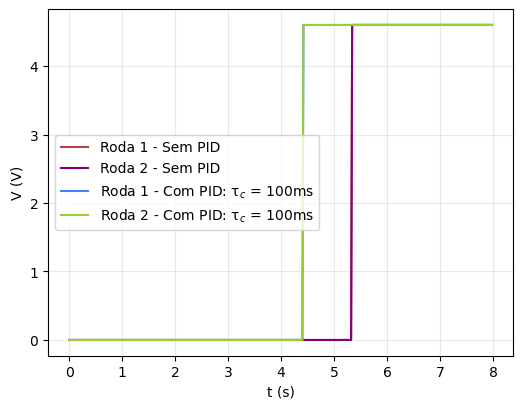

In [3]:
data = {} # dictionary to store data

fig_u, ax_u = plt.subplots(figsize = (6, 4.5))

for i, f in enumerate(files):
    d = np.loadtxt(data_dir / f).T # import data
    data[names[i]] = d # store in dictionary
    num = len(d[0]) # check size (must be 400)
    print(num)

    t = d[0]
    u1 = d[1]
    u2 = d[2]

    d[3] /= np.max(u1)
    d[4] /= np.max(u2)

    # check voltage is correct
    ax_u.plot(t, u1, color = plot_colors[2*i - 1] , label = f'Roda 1 - {names[i]}')
    ax_u.plot(t, u2, color = plot_colors[2*i] , label = f'Roda 2 - {names[i]}')
    ax_u.grid(color = grid_color, alpha = 0.5)
    ax_u.set_xlabel('t (s)')
    ax_u.set_ylabel('V (V)')
    ax_u.legend()

# Analysis
(com ajustes)

Sem PID
RODA 1
 - A = 4.74 (rad/s)/V
 - τ = 115 ms
 - PID
    - para τ = 0.2
         - k_c = 0.121
         - k_i = 1.054
    - para τ = 0.1
         - k_c = 0.241
         - k_i = 2.108


C:\Users\salom\AppData\Local\Temp\ipykernel_10636\111697313.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1 - np.exp(-t/tau))


RODA 2
 - A = 4.98 (rad/s)/V
 - τ = 110 ms
 - PID
    - para τ = 0.2
         - k_c = 0.111
         - k_i = 1.004
    - para τ = 0.1
         - k_c = 0.221
         - k_i = 2.008
PID médio
- para τ = 0.2
       - k_c = 0.116
       - k_i = 1.029
- para τ = 0.1
       - k_c = 0.231
       - k_i = 2.058



Com PID: τ$_c$ = 100ms
RODA 1
 - A = 4.51 (rad/s)/V
 - τ = 121 ms
RODA 2
 - A = 4.84 (rad/s)/V
 - τ = 120 ms





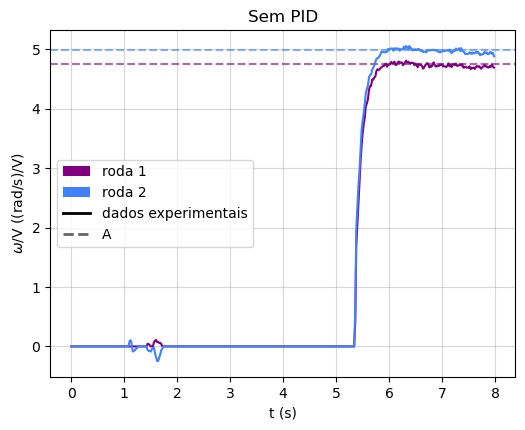

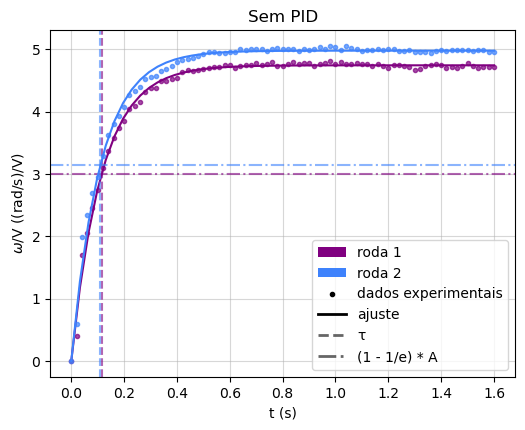

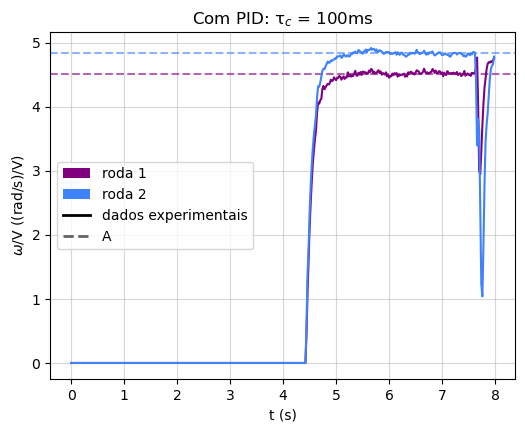

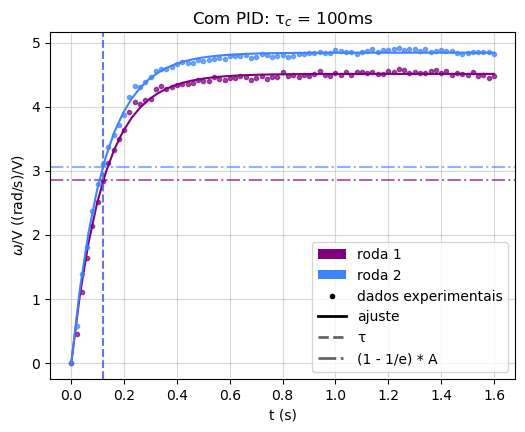

In [6]:
def wv (t, tau, A):
    return A * (1 - np.exp(-t/tau))

for i, key in enumerate(data):
    print(key)
    d = data[key]
    t = d[0]
    t_corr = t[n_start[i]:n_A_min[i]].copy()
    t_corr -= t_corr[0]
    w1 = d[3]
    w2 = d[4]
    ws = [w1, w2]

    # to store the values
    kcs = np.zeros((len(tau_ts), 2))
    kis = np.zeros((len(tau_ts), 2))

    fig_og, ax_og = plt.subplots(figsize = (6, 4.5))
    ax_og.grid(grid_color, alpha = 0.5)
    ax_og.set_title(key)
    ax_og.set_xlabel('t (s)')
    ax_og.set_ylabel(r'$\omega$/V ((rad/s)/V)')
    motor_lines = [
        Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(ws))
    ]
    motor_labels = [f'roda {k + 1}' for k in range(len(ws))]
    
    style_lines = [
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '--', alpha = 0.6)
    ]
    style_labels = ['dados experimentais', 'A']
    
    ax_og.legend(motor_lines + style_lines, motor_labels + style_labels)

    
    fig_f, ax_f = plt.subplots(figsize = (6, 4.5))
    ax_f.grid(grid_color, alpha = 0.5)
    ax_f.set_title(key)
    ax_f.set_xlabel('t (s)')
    ax_f.set_ylabel(r'$\omega$/V ((rad/s)/V)')
    motor_lines = [
        Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(ws))
    ]
    motor_labels = [f'roda {k + 1}' for k in range(len(ws))]

    style_lines = [
        Line2D([0], [0], color = 'black', lw = 2, marker = '.', linestyle = 'None'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-'),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '--', alpha = 0.6),
        Line2D([0], [0], color = 'black', lw = 2, linestyle = '-.', alpha = 0.6)
    ]
    style_labels = ['dados experimentais', 'ajuste', 'τ', '(1 - 1/e) * A']
    
    ax_f.legend(motor_lines + style_lines, motor_labels + style_labels)
    
    
    for j, w in enumerate(ws):
        w_corr = w[n_start[i]:n_A_min[i]]
        pars, cov = curve_fit(wv, t_corr, w_corr, maxfev=10000)
        tau, A = pars
        A_tau = (1 - 1/np.e)*A

        print(f"RODA {j + 1}\n - A = {A:.2f} (rad/s)/V")
        print(f" - τ = {tau*1000:.0f} ms")

        if PID_bol[i] == 0: # if no PID we will determine it
            print(' - PID')
            for k, tau_t in enumerate(tau_ts):
                print(f'    - para τ = {tau_t}')
                
                kc = tau/(tau_t * A)
                kcs[k, j] = kc
                print(f"         - k_c = {kc:.3f}")
    
                ki = kc/tau
                kis[k, j] = ki
                print(f"         - k_i = {ki:.3f}")
            
        ax_og.plot(t, w, label = f'Roda {j + 1}', color = plot_colors[j])
        ax_og.axhline(A, linestyle = '--', color = plot_colors[j], alpha = 0.6)

        fig_og.savefig(im_dir/f'all_{key}', dpi = 200, bbox_inches = 'tight')

        ax_f.plot(t_corr, w_corr, '.', color = plot_colors[j], alpha = 0.7)
        ax_f.plot(np.linspace(t_corr[0], t_corr[-1]), wv(np.linspace(t_corr[0], t_corr[-1]), *pars), color = plot_colors[j], label = f'Roda {j + 1}')
        ax_f.axvline(tau, linestyle = '--', color = plot_colors[j], alpha = 0.6)
        ax_f.axhline(A_tau, linestyle = '-.', color = plot_colors[j], alpha = 0.6) #label = '(1 - 1/e) * A'
        
        fig_f.savefig(im_dir/f'ajuste_{key}', dpi = 200, bbox_inches = 'tight')

    if PID_bol[i] == 0: # if no PID we will determine it
        print("PID médio")
        for k, tau_t in enumerate(tau_ts):
            print(f'- para τ = {tau_t}')
            kc_m = np.mean(kcs[k])
            print(f"       - k_c = {kc_m:.3f}")
    
            ki_m = np.mean(kis[k])
            print(f"       - k_i = {ki_m:.3f}")

    print('\n\n')